Trial 10 Complete [00h 01m 32s]
val_accuracy: 0.5191256999969482

Best val_accuracy So Far: 0.6229507923126221
Total elapsed time: 00h 33m 55s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 241ms/step - accuracy: 0.7093 - loss: 1.3197 - val_accuracy: 0.5082 - val_loss: 1.8005 - learning_rate: 1.0000e-04
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.7463 - loss: 1.2179 - val_accuracy: 0.4809 - val_loss: 1.9238 - learning_rate: 1.0000e-04
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.7707 - loss: 1.1662 - val_accuracy: 0.5628 - val_loss: 1.6274 - learning_rate: 1.0000e-04
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.8175 - loss: 0.9931 - val_accuracy: 0.7213 - val_loss: 1.2558 - learning_rate: 1.0000e-04
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.7950 - loss: 1.0008 - val_accuracy: 0.7486 - val_loss: 1.1468 - learning_rate: 1.0000e-04
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.8512 - loss: 0.8876 - val_accuracy: 0.7486 - val_loss: 1.0445 - learning_rate: 1.0000e-04
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy

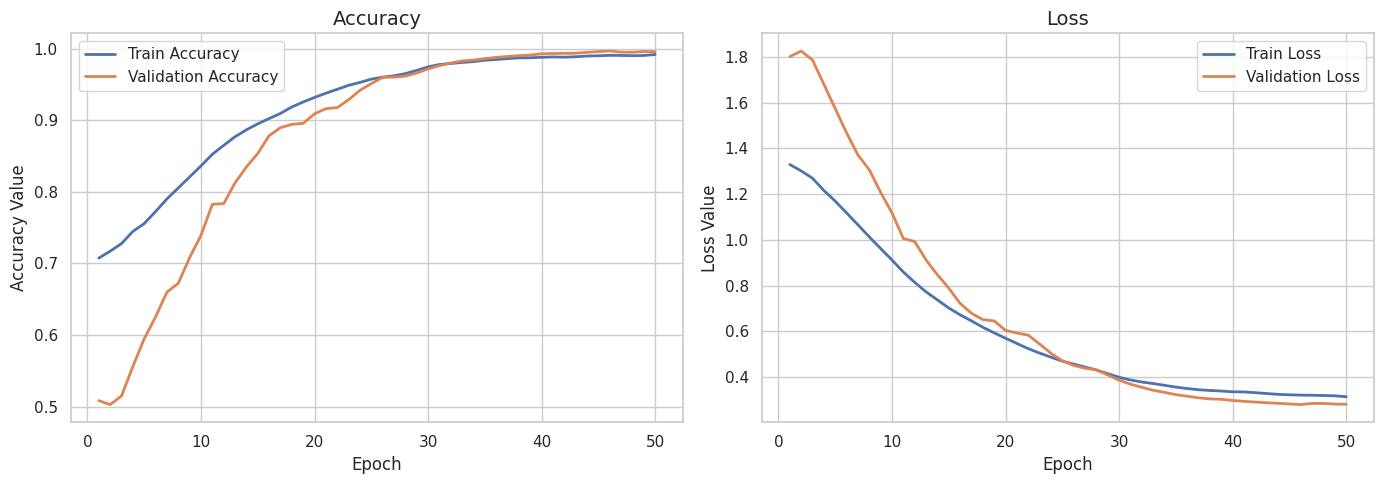

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step

Classification Report:
                                        precision    recall  f1-score   support

                       aloperia areata       1.00      1.00      1.00        15
                          beau_s lines       1.00      1.00      1.00         8
                           bluish nail       1.00      1.00      1.00        13
                              clubbing       1.00      1.00      1.00        12
                      darier_s disease       1.00      1.00      1.00        17
                                eczema       1.00      1.00      1.00        12
half and half nailes (Lindsay_s nails)       1.00      1.00      1.00        15
                           koilonychia       1.00      1.00      1.00         8
                           leukonychia       1.00      1.00      1.00         6
                     muehrck-e_s lines       1.00      1.00      1.00         9
                           onycholycis       1.00      1

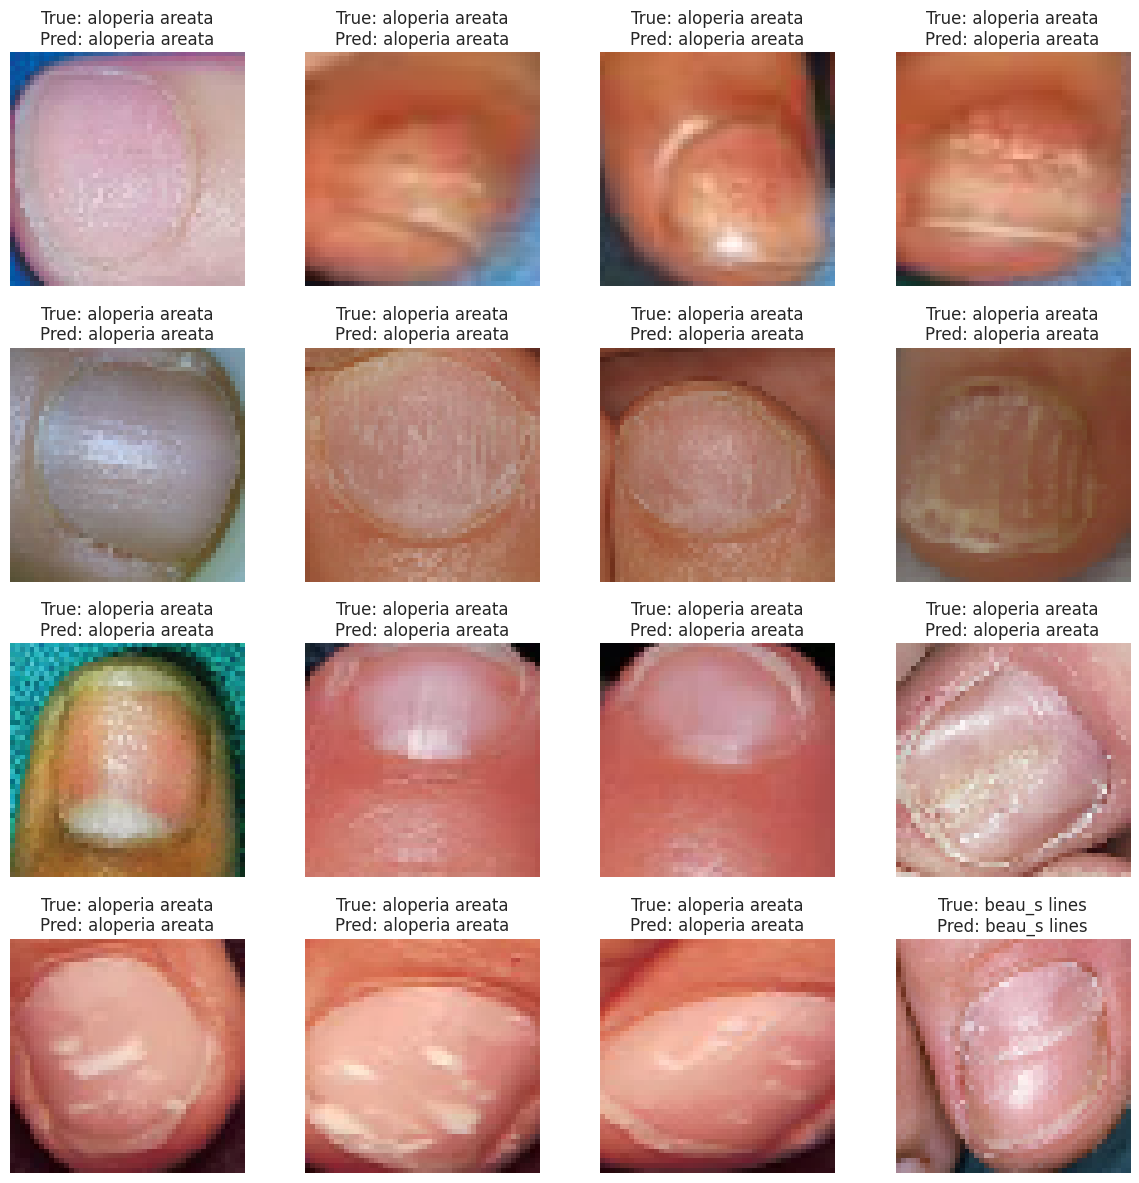

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 1.0000 - loss: 0.2680

Test Accuracy: 1.0000
Test Loss: 0.2703


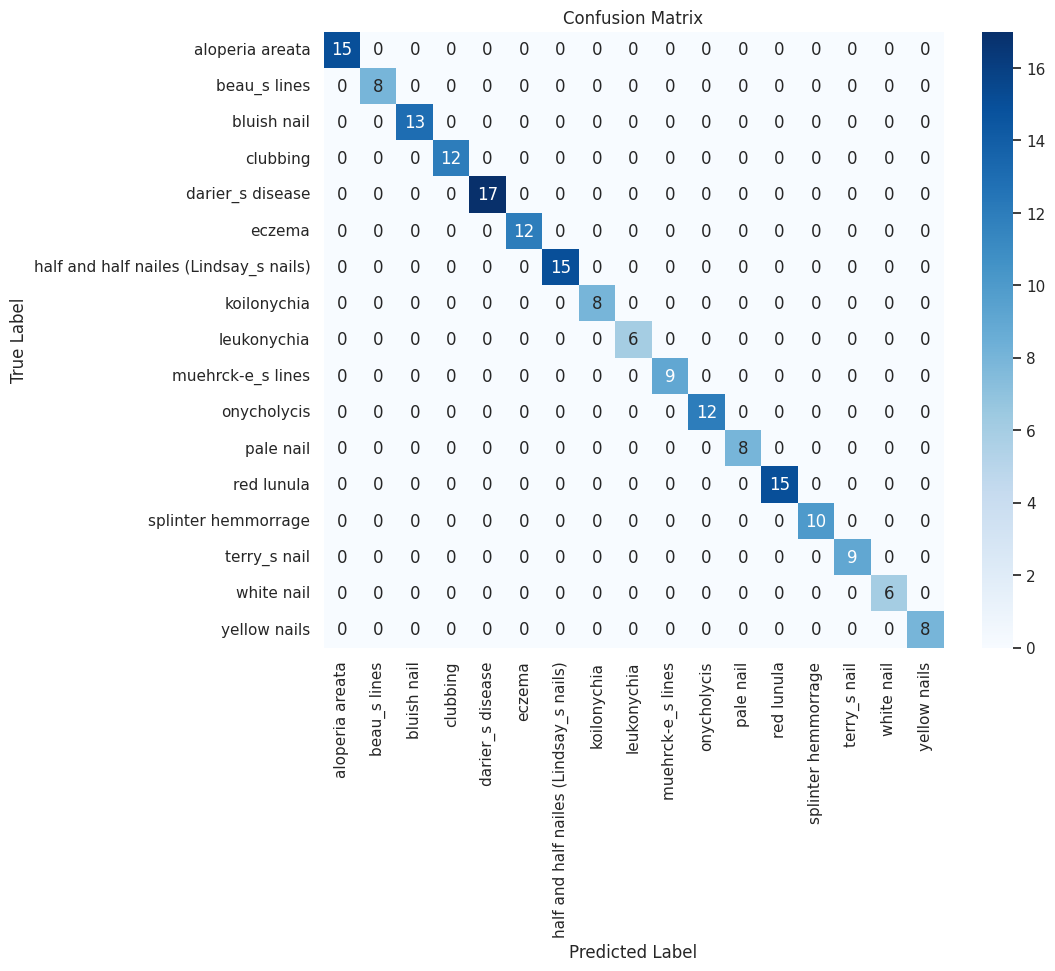


 Final Analysis:


Saving disease_deficiency.csv to disease_deficiency.csv
/content/drive/MyDrive/disease_deficiency.csv
Cleaned column names: ['disease', 'deficiency']
Dictionary created successfully.
{'aloperia areata': 'Iron and vitamin D Deficiency', "beau's lines": 'Zinc Deficiency', 'bluish nail': 'Vitamin B12 deficiency', "darier's disease": 'Vitamin A deficiency', 'eczema': 'Vitamin D deficiency', "half and half nails(Lindsay's nails)": 'tryptophan deficiency', 'koilonychia': 'Iron Deficiency', "mees' lines": 'Arsenic Poisoning', 'melanonychia': 'Vitamin B12 Deficiency', "muehrcke's Lines": 'Protein Deficiency', 'pale nails': 'Vitamin B12 Deficiency', 'onycholysis': 'Thyroid or Trauma Related', 'pitting': 'Psoriasis or Autoimmune', 'splinter hemorrhages': 'Vitamin C Deficiency', "terry's nails": 'Liver Disease (Protein Deficiency)', 'onychomycosis': 'Fungal Infection (Not Nutritional)', 'paronychia': 'Bacterial Infection (Not Nutritional)', 'brittle nails': 'Biotin Deficiency', 'onychorrhexis': '

In [ ]:
# model training
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import vgg16 as vgg
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import os
!pip install -U keras-tuner
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
import shutil
drive.mount('/content/drive')
train_dir = '/content/drive/MyDrive/Nail Disease DataSet/Train'
val_dir = '/content/drive/MyDrive/Nail Disease DataSet/Test'
IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 50
tuner_dir = '/content/drive/MyDrive/tuner_results'
project_name = 'nail_disease_tuning'
tuner_project_path = os.path.join(tuner_dir, project_name)
if os.path.exists(tuner_project_path):
    print(f"Clearing previous tuner results from: {tuner_project_path}")
    shutil.rmtree(tuner_project_path)
    print("Previous tuner results cleared.")
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
NUM_CLASSES = len(train_generator.class_indices)
label_dict = {v: k for k, v in train_generator.class_indices.items()}
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, verbose=1, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
def build_model(hp):
    base_model = vgg.VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    x = base_model.get_layer('block3_pool').output
    x = GlobalAveragePooling2D()(x)
    x = Dense(hp.Int('dense_units', 128, 512, step=64),
              kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(hp.Float('dropout_rate1', 0.4, 0.7, step=0.1))(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[1e-4, 5e-5, 1e-5])
        ),
        metrics=['accuracy']
    )
    return model
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory=tuner_dir,
    project_name=project_name
)
tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop],
    class_weight=class_weights_dict,
    verbose=1
)
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_history = best_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[lr_reduce, early_stop],
    verbose=1
)
best_model.save('/content/drive/MyDrive/nail_disease_model_tuned.h5')
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed
sns.set(style='whitegrid')
acc = smooth_curve(final_history.history['accuracy']) # Use smoothed accuracy
val_acc = smooth_curve(final_history.history['val_accuracy']) # Use smoothed validation accuracy
loss = smooth_curve(final_history.history['loss']) # Use smoothed loss
val_loss = smooth_curve(final_history.history['val_loss']) # Use smoothed validation loss
epochs_range = range(1, len(acc) + 1)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x=epochs_range, y=acc, label='Train Accuracy', linewidth=2.0)
sns.lineplot(x=epochs_range, y=val_acc, label='Validation Accuracy', linewidth=2.0)
plt.title('Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
sns.lineplot(x=epochs_range, y=loss, label='Train Loss', linewidth=2.0)
sns.lineplot(x=epochs_range, y=val_loss, label='Validation Loss', linewidth=2.0)
plt.title('Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
val_generator.reset()
predictions = best_model.predict(val_generator, steps=len(val_generator), verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
misclassified_indices = np.where(predicted_classes != true_classes)[0]
print("\nClassification Report:")
# Get the unique labels present in the true_classes
unique_labels = np.unique(true_classes)
# Get the corresponding target names
target_names_for_report = [label_dict[label] for label in unique_labels]
print(classification_report(true_classes, predicted_classes, labels=unique_labels, target_names=target_names_for_report))
def plot_sample_predictions(model, generator, label_dict, n=16):
    x, y = next(generator)
    preds = model.predict(x)
    pred_classes = preds.argmax(axis=1)
    true_classes = y.argmax(axis=1)
    plt.figure(figsize=(12, 12))
    for i in range(min(n, len(x))):
        plt.subplot(4, 4, i + 1)
        plt.imshow(x[i])
        plt.title(f"True: {label_dict[true_classes[i]]}\nPred: {label_dict[pred_classes[i]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
plot_sample_predictions(best_model, val_generator, label_dict)
val_generator.reset()
test_loss, test_accuracy = best_model.evaluate(val_generator, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\n Final Analysis:")

from google.colab import files
uploaded = files.upload()
!mv disease_deficiency.csv /content/drive/MyDrive/
!ls /content/drive/MyDrive/disease_deficiency.csv
import pandas as pd
import os
csv_path = '/content/drive/MyDrive/disease_deficiency.csv'

if not os.path.exists(csv_path):
    print(f"Error: File not found at {csv_path}")
else:
    df = pd.read_csv(csv_path, encoding='utf-8-sig', on_bad_lines='skip')
    df.columns = df.columns.str.strip()
    print("Cleaned column names:", df.columns.tolist())

    expected_columns = ['disease', 'deficiency']
    if all(col in df.columns for col in expected_columns):
        disease_deficiency_dict = dict(zip(df['disease'], df['deficiency']))
        print("Dictionary created successfully.")
        print(disease_deficiency_dict)
    else:
        missing = [col for col in expected_columns if col not in df.columns]
        print(f"Error: Required column(s) not found: {missing}")
import pandas as pd
csv_path = '/content/drive/MyDrive/disease_deficiency.csv'
df_mapping = pd.read_csv(csv_path, on_bad_lines='skip')
disease_deficiency_dict = dict(zip(df_mapping['disease'], df_mapping['deficiency']))


Upload an image of the nail:


Saving darrier1.jpg to darrier1 (2).jpg

Image loaded successfully: darrier1 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


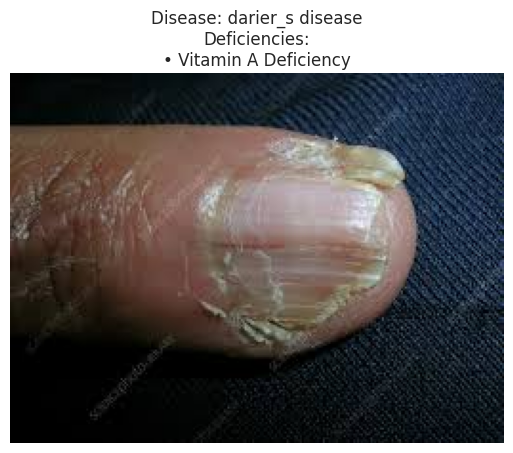


🩺 **Nail Disease:** darier_s disease
💊 **Associated Vitamin Deficiencies:**
• Vitamin A Deficiency


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import io
# Base alias mapping
alias_to_standard = {
    "aloperia areata": "alopecia areata",
    "beau's lines": "beau's lines",
    "bluish nail": "bluish nails",
    "darier's disease": "darier's disease",
    "eczema": "eczema",
    "half and half nails(lindsay's nails)": "half and half nails(lindsay's nails)",
    "clubbing": "clubbing",
    "koilonychia": "koilonychia",
    "leukonychia": "leukonychia",
    "mees' lines": "mees' lines",
    "melanonychia": "melanonychia",
    "muehrcke's lines": "muehrcke's lines",
    "pale nails": "pale nails",
    "onycholysis": "onycholysis",
    "pitting": "pitting",
    "splinter hemorrhages": "splinter hemorrhages",
    "terry's nails": "terry's nails",
    "yellow nails": "yellow nails",
    "white nails": "white nails",
    "onychomycosis": "onychomycosis",
    "paronychia": "paronychia",
    "brittle nails": "brittle nails",
    "onychorrhexis": "onychorrhexis",
    "subungual hematoma": "subungual hematoma"
}

# Auto-generated alias mapping (merged)
auto_generated_alias_to_standard = {
    "terry_s nail": "terry's nails",
    "beaus lines": "beau's lines",
    "splinter hemmorrage": "splinter hemorrhages",
    "yellow nail": "yellow nails",
    "bluish nail": "bluish nails",
    "mees lines": "mees' lines",
    "alopecia": "alopecia areata",
    "onychomicosis": "onychomycosis",
    "muehrckes lines": "muehrcke's lines",
    "white nail": "white nails",
    "brittle nail": "brittle nails",
    "paronychia infection": "paronychia",
    "dariers disease": "darier's disease",
    "half and half nail": "half and half nails(lindsay's nails)", # Corrected alias
    "subungual hematoma bruise": "subungual hematoma",
    "onichorrhexis": "onychorrhexis",
    "half and half nailes (lindsay_s nails)": "half and half nails(lindsay's nails)", # Added alias from model output
    "beau s lines": "beau's lines", # Added alias for "beau s lines"
    "pale nail": "pale nails", # Added alias for "pale nail"
    "darier s disease": "darier's disease" # Added alias for "darier s disease"
}
alias_to_standard.update(auto_generated_alias_to_standard)

# Standard disease to deficiencies list
standard_disease_to_deficiency_list = {
    "alopecia areata": ["Iron Deficiency", "Vitamin D Deficiency"],
    "beau's lines": ["Zinc Deficiency"],
    "bluish nails": ["Vitamin B12 Deficiency"],
    "darier's disease": ["Vitamin A Deficiency"],
    "eczema": ["Vitamin D Deficiency"],
    "half and half nails(lindsay's nails)": ["Tryptophan Deficiency"],
    "clubbing": ["Oxygen Deficiency (Chronic Disease)", "Iodine Deficiency"],
    "koilonychia": ["Iron Deficiency"],
    "leukonychia": ["Zinc Deficiency", "Calcium Deficiency", "Iron Deficiency"],
    "mees' lines": ["Arsenic Poisoning"],
    "melanonychia": ["Vitamin B12 Deficiency"],
    "muehrcke's lines": ["Protein Deficiency"],
    "pale nails": ["Vitamin B12 Deficiency"],
    "onycholysis": ["Thyroid Related", "Trauma Related"],
    "pitting": ["Psoriasis", "Autoimmune"],
    "splinter hemorrhages": ["Vitamin C Deficiency"],
    "terry's nails": ["Liver Disease", "Protein Deficiency"],
    "yellow nails": ["Lymphatic Obstruction", "Vitamin E Deficiency"],
    "white nails": ["Iron Deficiency", "Zinc Deficiency", "Calcium Deficiency"],
    "onychomycosis": ["Fungal Infection (Not Nutritional)"],
    "paronychia": ["Bacterial Infection (Not Nutritional)"],
    "brittle nails": ["Biotin Deficiency"],
    "onychorrhexis": ["Iron Deficiency"],
    "subungual hematoma": ["Trauma", "Hemorrhage"]
}


# Upload image
print("\nUpload an image of the nail:")
uploaded = files.upload()

if uploaded:
    image_name = list(uploaded.keys())[0]
    image_content = uploaded[image_name]

    try:
        img = Image.open(io.BytesIO(image_content))
        print(f"\nImage loaded successfully: {image_name}")

        # Preprocess
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = img_to_array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        if best_model:
            prediction = best_model.predict(img_array)
            predicted_class_index = np.argmax(prediction)
            predicted_class_name = label_dict.get(predicted_class_index)

            if predicted_class_name:
                lookup_name = predicted_class_name.lower().strip().replace("_", " ")
                standardized_name = alias_to_standard.get(lookup_name, lookup_name) # Standardize the predicted name
                deficiency_list = standard_disease_to_deficiency_list.get(standardized_name)

                # Display image
                plt.imshow(img)
                plt.axis('off')
                if deficiency_list:
                    deficiency_text = "\n• " + "\n• ".join(deficiency_list)
                    plt.title(f"Disease: {predicted_class_name}\nDeficiencies:{deficiency_text}", fontsize=12)
                else:
                    plt.title(f"Disease: {predicted_class_name}\nNo deficiency info available", fontsize=12)
                plt.show()

                # Console output
                print(f"\n🩺 **Nail Disease:** {predicted_class_name}")
                if deficiency_list:
                    print("💊 **Associated Vitamin Deficiencies:**")
                    for item in deficiency_list:
                        print(f"• {item}")
                else:
                    print("💊 **Associated Vitamin Deficiencies:** No deficiency info available")
            else:
                # Unknown class index
                print(f"\n⚠️ Model predicted a class index not found in label_dict: {predicted_class_index}")
                print("🩺 **Nail Disease:** Unknown")
                print("💊 **Associated Vitamin Deficiencies:** No prediction available")

                plt.imshow(img)
                plt.axis('off')
                plt.title("Unknown Nail Condition - Please Verify", fontsize=12)
                plt.show()
        else:
            print("❌ Model not loaded.")
    except Exception as e:
        print(f"Image processing error: {e}")
else:
    print("No image uploaded.")

In [ ]:
import tensorflow as tf
import pandas as pd
import os
import numpy as np

def load_metadata(csv_path):
    return pd.read_csv(csv_path)

def preprocess_image(image_path, target_size=(256, 256)):
    image = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
    image = tf.keras.preprocessing.image.img_to_array(image) / 255.0
    return image

def preprocess_mask(mask_path, target_size=(256, 256), num_classes=6):
    mask = tf.keras.preprocessing.image.load_img(mask_path, color_mode='grayscale', target_size=target_size)
    mask = tf.keras.preprocessing.image.img_to_array(mask).squeeze().astype(np.uint8)
    # One-hot encode: shape (H, W, C)
    mask = tf.one_hot(mask, num_classes).numpy()
    return mask

def data_generator(metadata, image_dir, mask_dir, batch_size=8, num_classes=6, num_diseases=18):
    while True:
        metadata = metadata.sample(frac=1).reset_index(drop=True)  # shuffle each epoch
        for i in range(0, len(metadata), batch_size):
            batch = metadata.iloc[i:i+batch_size]
            X, Y_seg, Y_cls = [], [], []
            for _, row in batch.iterrows():
                img_path = os.path.join(image_dir, row['filename'])
                mask_path = os.path.join(mask_dir, os.path.basename(row['mask_path']))
                X.append(preprocess_image(img_path))
                Y_seg.append(preprocess_mask(mask_path, num_classes=num_classes))
                Y_cls.append(int(row['disease']))  # Make sure disease column is encoded as integer

            yield np.array(X), {'seg_output': np.array(Y_seg), 'disease_output': np.array(Y_cls)}
import matplotlib.pyplot as plt
import cv2

# Color map for visualizing segmentation zones
ZONE_COLORS = {
    0: (0, 255, 0),       # Nail plate – Green
    1: (255, 255, 255),   # Lunula – White
    2: (0, 0, 255),       # Cuticle – Blue
    3: (128, 0, 128),     # Nail Fold – Purple
    4: (255, 255, 0),     # Nail Tip – Yellow
    5: (0, 0, 0)          # Background (optional)
}

def visualize_segmentation(image, seg_mask):
    """
    image: numpy array (H, W, 3)
    seg_mask: predicted mask, shape (H, W)
    """
    overlay = np.zeros_like(image, dtype=np.uint8)
    for label, color in ZONE_COLORS.items():
        overlay[seg_mask == label] = color

    blended = cv2.addWeighted((image * 255).astype(np.uint8), 0.7, overlay, 0.3, 0)
    plt.figure(figsize=(6, 6))
    plt.imshow(blended)
    plt.axis('off')
    plt.title("Zone Highlight Overlay")
    plt.show()
def build_model_with_deficiency(input_shape=(256, 256, 3), num_diseases=18, num_zones=6, num_deficiencies=6):
    inputs = tf.keras.Input(shape=input_shape)
    base_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_tensor=inputs)
    x = base_model.output

    # Shared Features
    gap = tf.keras.layers.GlobalAveragePooling2D()(x)
    shared_dense = tf.keras.layers.Dense(256, activation='relu')(gap)

    # Disease classification
    disease_output = tf.keras.layers.Dense(num_diseases, activation='softmax', name='disease_output')(shared_dense)

    # Deficiency classification
    deficiency_output = tf.keras.layers.Dense(num_deficiencies, activation='softmax', name='deficiency_output')(shared_dense)

    # Segmentation decoder
    seg = tf.keras.layers.Conv2DTranspose(256, 3, strides=2, padding='same', activation='relu')(x)
    seg = tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(seg)
    seg = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(seg)
    seg = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(seg)
    seg_output = tf.keras.layers.Conv2D(num_zones, 1, activation='softmax', name='seg_output')(seg)

    model = tf.keras.Model(inputs, [seg_output, disease_output, deficiency_output])
    return model

model = build_model_with_deficiency() # Build the model

model.compile(
    optimizer='adam',
    loss={
        'seg_output': 'categorical_crossentropy',
        'disease_output': 'sparse_categorical_crossentropy',
        'deficiency_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'seg_output': 1.0,
        'disease_output': 1.0,
        'deficiency_output': 0.8
    },
    metrics={
        'seg_output': ['accuracy'],
        'disease_output': ['accuracy'],
        'deficiency_output': ['accuracy']
    }
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import os
import zipfile
from PIL import Image, ImageDraw
import pandas as pd

# Step 1: Set input/output paths
zip_path = "/content/drive/MyDrive/DATASET.zip"
extracted_path = "/content/drive/MyDrive/temp_dataset"
output_root = "/content/drive/MyDrive/processed_dataset"

# Step 2: Extract ZIP file
os.makedirs(extracted_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

# Step 3: Create output directories
images_out = os.path.join(output_root, "images")
masks_out = os.path.join(output_root, "masks")
os.makedirs(images_out, exist_ok=True)
os.makedirs(masks_out, exist_ok=True)

# Step 4: Function to create dummy zone mask (5 horizontal zones)
def create_zone_mask(image_size=(256, 256), zones=5):
    mask = Image.new('L', image_size, color=255)
    draw = ImageDraw.Draw(mask)
    width, height = image_size
    zone_height = height // zones
    for i in range(zones):
        top = i * zone_height
        bottom = (i + 1) * zone_height
        draw.rectangle([0, top, width, bottom], fill=i)
    return mask

# Step 5: Process images and create metadata
metadata = []
img_counter = 0

for root, dirs, files in os.walk(extracted_path):
    disease = os.path.basename(root)
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img_path = os.path.join(root, file)
                img = Image.open(img_path).convert('RGB').resize((256, 256))
                mask = create_zone_mask()

                img_name = f"nail_{img_counter}.png"
                mask_name = f"nail_{img_counter}_mask.png"

                img.save(os.path.join(images_out, img_name))
                mask.save(os.path.join(masks_out, mask_name))

                metadata.append({
                    'filename': img_name,
                    'disease': disease,
                    'mask_path': f"masks/{mask_name}"
                })

                img_counter += 1

            except Exception as e:
                print(f"Failed: {file} | Error: {e}")

# Step 6: Save metadata CSV
df = pd.DataFrame(metadata)
df.to_csv(os.path.join(output_root, "metadata.csv"), index=False)
print(f"Processed {img_counter} images.")
df.head()


Processed 1443 images.


,filename,disease,mask_path
0,nail_0.png,aloperia areata,masks/nail_0_mask.png
1,nail_1.png,aloperia areata,masks/nail_1_mask.png
2,nail_2.png,aloperia areata,masks/nail_2_mask.png
3,nail_3.png,aloperia areata,masks/nail_3_mask.png
4,nail_4.png,aloperia areata,masks/nail_4_mask.png


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('filename').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('mask_path').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['mask_path'].value_counts()
    for x_label, grp in _df_2.groupby('filename')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('filename')
_ = plt.ylabel('mask_path')

Starting to process images from: /content/drive/MyDrive/temp_dataset/DATASET
✅ Processed 1443 images.
📊 Showing 1 sample per disease:


/tmp/ipython-input-10-3687487170.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = df.groupby('disease').apply(lambda x: x.sample(1) if len(x) > 0 else None).dropna().reset_index(drop=True)


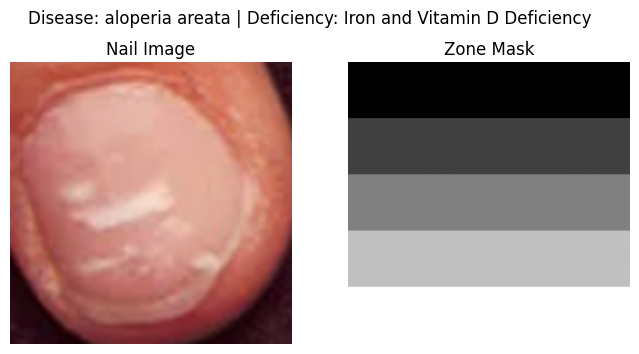

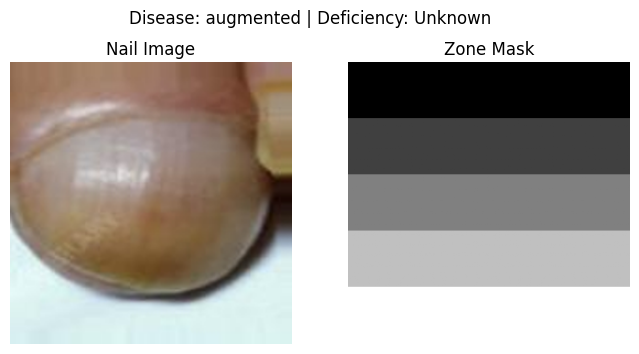

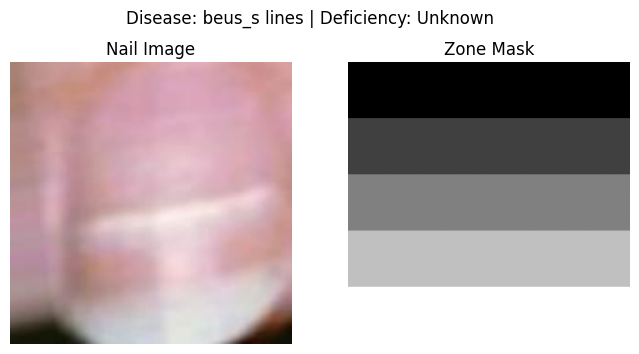

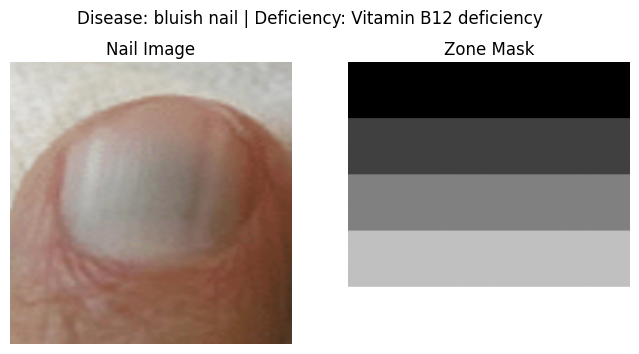

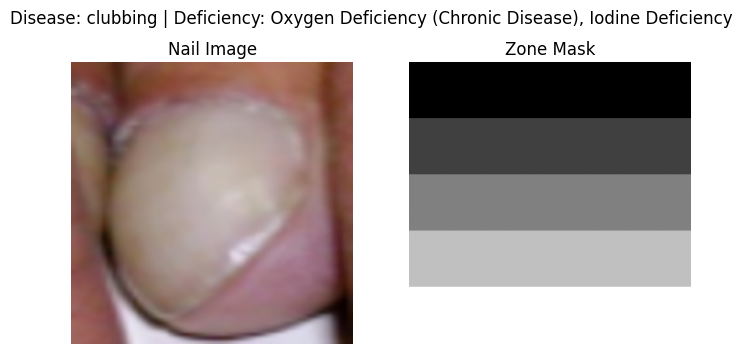

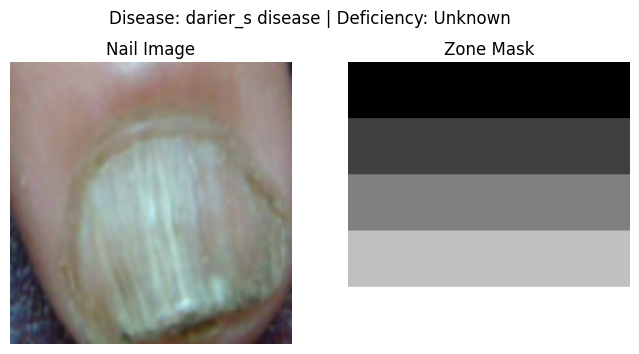

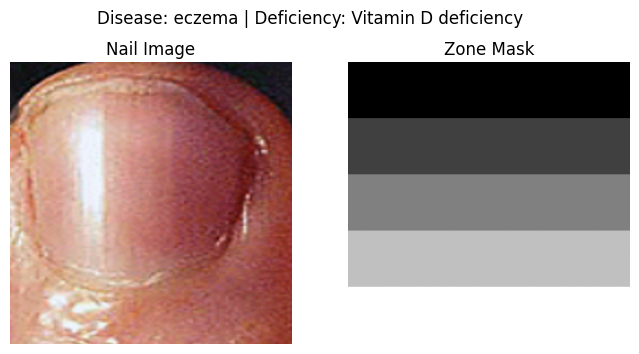

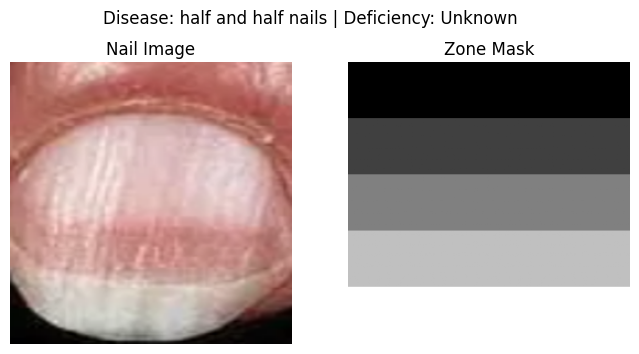

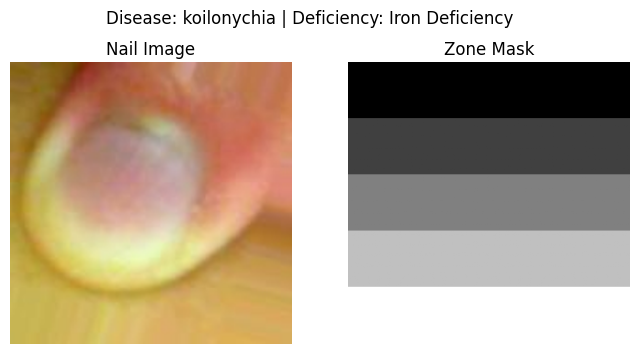

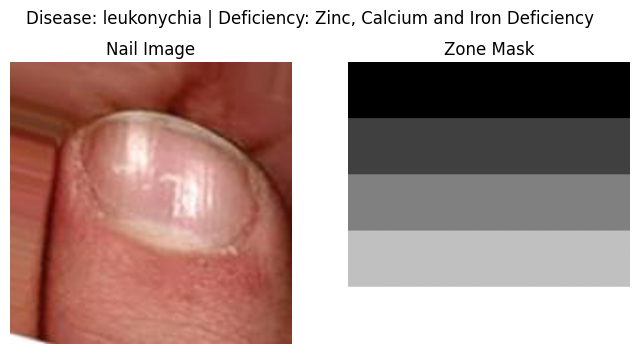

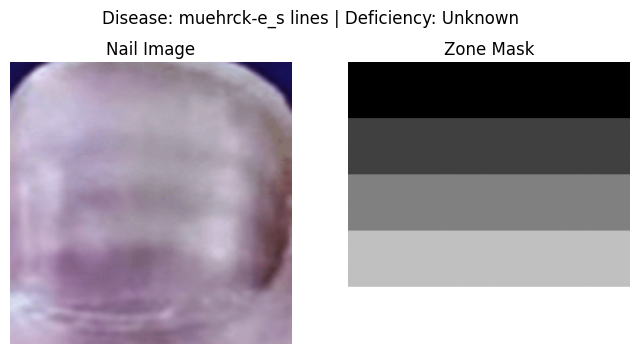

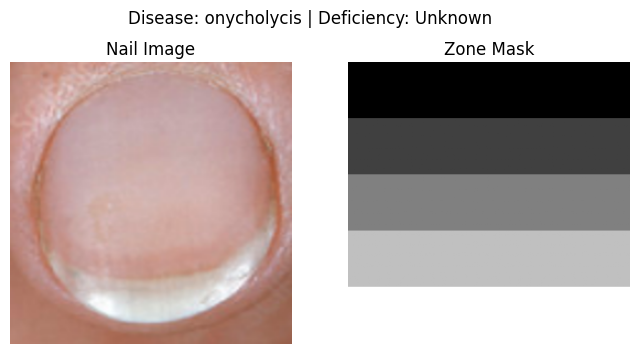

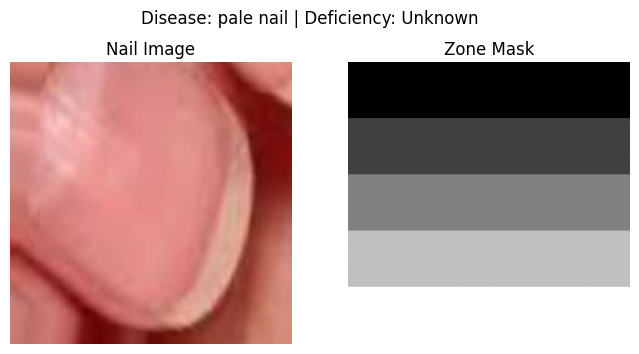

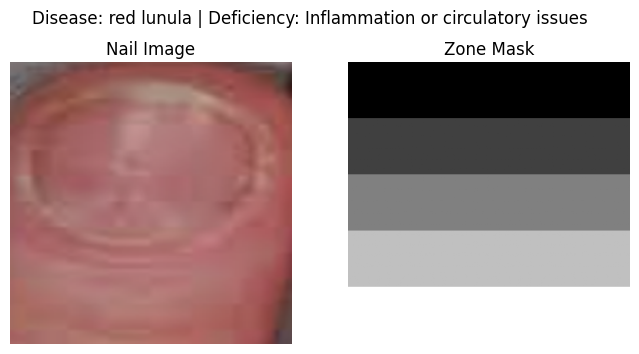

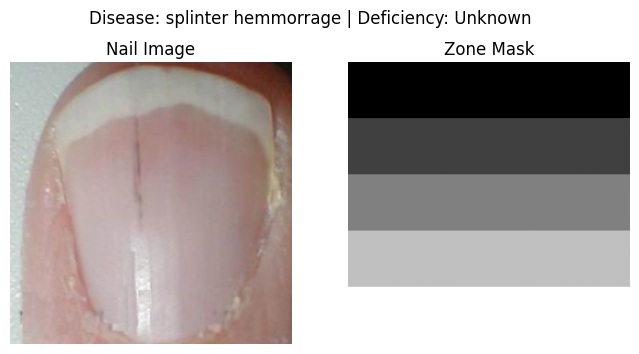

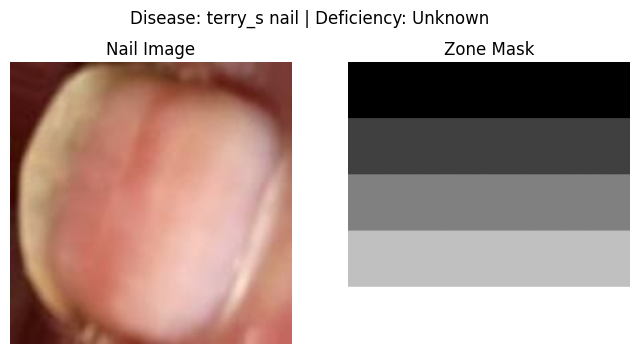

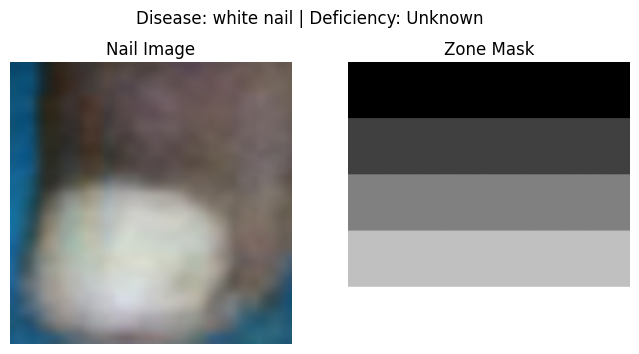

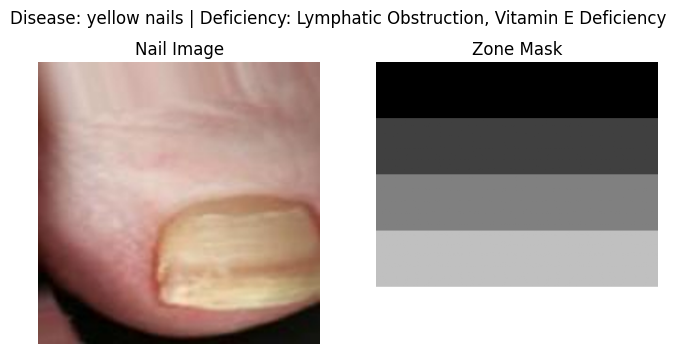

In [ ]:
import os
import pandas as pd
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
input_root = "/content/drive/MyDrive/temp_dataset/DATASET"
output_root = "/content/drive/MyDrive/processed_dataset"
os.makedirs(output_root, exist_ok=True)

images_out = os.path.join(output_root, "images")
masks_out = os.path.join(output_root, "masks")
os.makedirs(images_out, exist_ok=True)
os.makedirs(masks_out, exist_ok=True)

# Deficiency map
deficiency_map = {
    "aloperia areata": "Iron and Vitamin D Deficiency",
    "beau's lines": "Zinc Deficiency",
    "bluish nail": "Vitamin B12 deficiency",
    "darier's disease": "Vitamin A deficiency",
    "eczema": "Vitamin D deficiency",
    "half and half nails(Lindsay's nails)": "Tryptophan deficiency",
    "clubbing": "Oxygen Deficiency (Chronic Disease), Iodine Deficiency",
    "koilonychia": "Iron Deficiency",
    "leukonychia": "Zinc, Calcium and Iron Deficiency",
    "mees' lines": "Arsenic Poisoning",
    "melanonychia": "Vitamin B12 Deficiency",
    "muehrcke's lines": "Protein Deficiency",
    "pale nails": "Vitamin B12 Deficiency",
    "onycholysis": "Thyroid or Trauma Related",
    "pitting": "Psoriasis or Autoimmune",
    "splinter hemorrhages": "Vitamin C Deficiency",
    "terry's nails": "Liver Disease (Protein Deficiency)",
    "yellow nails": "Lymphatic Obstruction, Vitamin E Deficiency",
    "white nails": "Iron, Zinc, Calcium Deficiency",
    "onychomycosis": "Fungal Infection (Not Nutritional)",
    "paronychia": "Bacterial Infection (Not Nutritional)",
    "brittle nails": "Biotin Deficiency",
    "onychorrhexis": "Iron Deficiency",
    "subungual hematoma": "Trauma or Hemorrhage",
    "red lunula": "Inflammation or circulatory issues"
}

# Create dummy mask function
def create_zone_mask(image_size=(256, 256), zones=5):
    mask = Image.new('L', image_size, color=255)  # background
    draw = ImageDraw.Draw(mask)
    width, height = image_size
    zone_height = height // zones
    for i in range(zones):
        top = i * zone_height
        bottom = (i + 1) * zone_height
        draw.rectangle([0, top, width, bottom], fill=i)
    return mask

# Process images
metadata = []
img_counter = 0

print(f"Starting to process images from: {input_root}") # Added print statement

for root, dirs, files in os.walk(input_root):
    # Ensure we are not using the 'DATASET' folder name itself as a disease
    if os.path.basename(root) != 'DATASET':
        disease = os.path.basename(root).lower().strip()
    else:
        # Skip the top-level 'DATASET' folder if it contains files directly (unlikely but safe)
        continue

    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img_path = os.path.join(root, file)
                img = Image.open(img_path).convert('RGB').resize((256, 256))
                mask = create_zone_mask()

                img_name = f"nail_{img_counter}.png"
                mask_name = f"nail_{img_counter}_mask.png"

                img.save(os.path.join(images_out, img_name))
                mask.save(os.path.join(masks_out, mask_name))

                deficiency = deficiency_map.get(disease, "Unknown")

                metadata.append({
                    'filename': img_name,
                    'disease': disease,
                    'mask_path': f"masks/{mask_name}",
                    'deficiency': deficiency
                })

                img_counter += 1

            except Exception as e:
                print(f"Failed: {file} | Error: {e}")

# Added check for empty metadata before proceeding
if not metadata:
    print("Error: No images were processed from the specified input_root.")
    print("Please verify the input_root path and the contents of the directory.")
else:
    print(f"✅ Processed {img_counter} images.")

    # Save metadata
    df = pd.DataFrame(metadata)
    df.to_csv(os.path.join(output_root, "metadata.csv"), index=False)

    # Load metadata back (optional but clean)
    df = pd.read_csv(os.path.join(output_root, "metadata.csv"))
    # Ensure 'disease' column exists after reading (it should if metadata was not empty)
    if 'disease' in df.columns:
        df['disease'] = df['disease'].str.lower().str.strip()
        # Re-apply deficiency mapping in case of inconsistencies, using the already defined map
        df['deficiency'] = df['disease'].map(deficiency_map).fillna("Unknown")


        # ✅ RANDOM SAMPLE DISPLAY (1 per disease)
        print("📊 Showing 1 sample per disease:")

        unique_diseases = df['disease'].unique()
        # Ensure there are samples before trying to group and sample
        if not df.empty:
            # Use .sample(1) with try-except or check group size to avoid error if a disease has only one image
            samples = df.groupby('disease').apply(lambda x: x.sample(1) if len(x) > 0 else None).dropna().reset_index(drop=True)

            for _, row in samples.iterrows():
                img_path = os.path.join(output_root, "images", row['filename'])
                mask_path = os.path.join(output_root, row['mask_path'])

                # Added check if files exist before trying to open
                if os.path.exists(img_path) and os.path.exists(mask_path):
                    img = Image.open(img_path)
                    mask = Image.open(mask_path)

                    plt.figure(figsize=(8, 4))
                    plt.suptitle(f"Disease: {row['disease']} | Deficiency: {row['deficiency']}", fontsize=12)
                    plt.subplot(1, 2, 1)
                    plt.imshow(img)
                    plt.title("Nail Image")
                    plt.axis("off")
                    plt.subplot(1, 2, 2)
                    plt.imshow(mask, cmap='gray')
                    plt.title("Zone Mask")
                    plt.axis("off")
                    plt.show()
                else:
                    print(f"Warning: Image or mask file not found for {row['filename']}")
        else:
            print("No samples to display as the DataFrame is empty.")
    else:
         print("Error: 'disease' column not found in the DataFrame after reading the CSV.")

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# Paths
dataset_dir = "/content/drive/MyDrive/processed_dataset"
image_dir = os.path.join(dataset_dir, "images")
mask_dir = os.path.join(dataset_dir, "masks")
metadata_csv = os.path.join(dataset_dir, "metadata.csv")

# Params
IMG_SIZE = 128
NUM_ZONES = 5

# Load metadata
df = pd.read_csv(metadata_csv)
df['disease'] = df['disease'].str.lower().str.strip()
class_names = sorted(df['disease'].unique())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
num_classes = len(class_names)

# Load images/masks/labels
def load_image_mask_label(row):
    img_path = os.path.join(image_dir, row['filename'])
    mask_path = os.path.join(dataset_dir, row['mask_path'])

    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0

    mask = Image.open(mask_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    mask = np.clip(np.array(mask), 0, NUM_ZONES - 1)
    mask = tf.keras.utils.to_categorical(mask, num_classes=NUM_ZONES)

    label = class_to_idx[row['disease']]
    return img.astype(np.float32), mask.astype(np.float32), label

# Load all data into memory
print("Loading images and masks into NumPy arrays...")
X, Y_mask, Y_label = [], [], []
for _, row in df.iterrows():
    img, mask, label = load_image_mask_label(row)
    X.append(img)
    Y_mask.append(mask)
    Y_label.append(label)
X = np.array(X)
Y_mask = np.array(Y_mask)
Y_label = np.array(Y_label)
print("Loaded", len(X), "images.")
print("Image shape:", X.shape)
print("Mask shape:", Y_mask.shape)
print("Label shape:", Y_label.shape)

# Split
from sklearn.model_selection import train_test_split
X_train, X_val, Y_mask_train, Y_mask_val, Y_label_train, Y_label_val = train_test_split(
    X, Y_mask, Y_label, test_size=0.2, random_state=42)

print("\nData split into training and validation sets.")
print("X_train shape:", X_train.shape)
print("Y_label_train shape:", Y_label_train.shape)
print("Y_mask_train shape:", Y_mask_train.shape)

# Build model
def build_model(input_shape=(128, 128, 3), num_classes=18, num_zones=5):
    inputs = layers.Input(shape=input_shape)
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)
    x = base_model.output
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)

    # Classification head
    class_branch = layers.GlobalAveragePooling2D()(x)
    class_branch = layers.Dense(128, activation='relu')(class_branch)
    class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(class_branch)

    # Segmentation head
    seg = layers.Conv2DTranspose(256, 3, strides=2, padding='same', activation='relu')(x)
    seg = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(seg)
    seg = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(seg)
    seg = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(seg)
    seg = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(seg)
    mask_output = layers.Conv2D(num_zones, 1, activation='softmax', name='mask_output')(seg)

    return models.Model(inputs=inputs, outputs=[class_output, mask_output])

model = build_model(input_shape=(128, 128, 3), num_classes=num_classes, num_zones=NUM_ZONES)
model.compile(
    optimizer='adam',
    loss={
        'class_output': 'sparse_categorical_crossentropy',
        'mask_output': 'categorical_crossentropy',
    },
    metrics={
        'class_output': 'accuracy',
        'mask_output': 'accuracy',
    },
    loss_weights={'class_output': 1.0, 'mask_output': 1.0}
)

# Train
print("\nStarting model training with NumPy arrays...")
history = model.fit(
    x=X_train,
    y={
        'class_output': Y_label_train,
        'mask_output': Y_mask_train
    },
    validation_data=(
        X_val,
        {
            'class_output': Y_label_val,
            'mask_output': Y_mask_val
        }
    ),
    batch_size=2,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    ]
)

# Save model
model.save("/content/drive/MyDrive/nail_multitask_model_v2.h5")
print("✅ Model saved.")

Loading images and masks into NumPy arrays...
Loaded 1443 images.
Image shape: (1443, 128, 128, 3)
Mask shape: (1443, 128, 128, 5)
Label shape: (1443,)

Data split into training and validation sets.
X_train shape: (1154, 128, 128, 3)
Y_label_train shape: (1154,)
Y_mask_train shape: (1154, 128, 128, 5)


/tmp/ipython-input-11-924478694.py:71: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting model training with NumPy arrays...
Epoch 1/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - class_output_accuracy: 0.2211 - class_output_loss: 3.0412 - loss: 3.6161 - mask_output_accuracy: 0.7718 - mask_output_loss: 0.5750 - val_class_output_accuracy: 0.2630 - val_class_output_loss: 2.7437 - val_loss: 4.8005 - val_mask_output_accuracy: 0.7995 - val_mask_output_loss: 2.0434
Epoch 2/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - class_output_accuracy: 0.2857 - class_output_loss: 2.6631 - loss: 2.6654 - mask_output_accuracy: 0.9996 - mask_output_loss: 0.0023 - val_class_output_accuracy: 0.2630 - val_class_output_loss: 2.6831 - val_loss: 2.7604 - val_mask_output_accuracy: 0.9913 - val_mask_output_loss: 0.0730
Epoch 3/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - class_output_accuracy: 0.2782 - class_output_loss: 2.6904 - loss: 2.7083 - mask_output_accuracy: 0.9973 - mask_output_loss: 0.0179 - val_class_output_accuracy: 0.2630 - 

✅ Model saved.


📥 Loading model...


📁 Please upload a nail image...


Saving download.jpeg to download (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


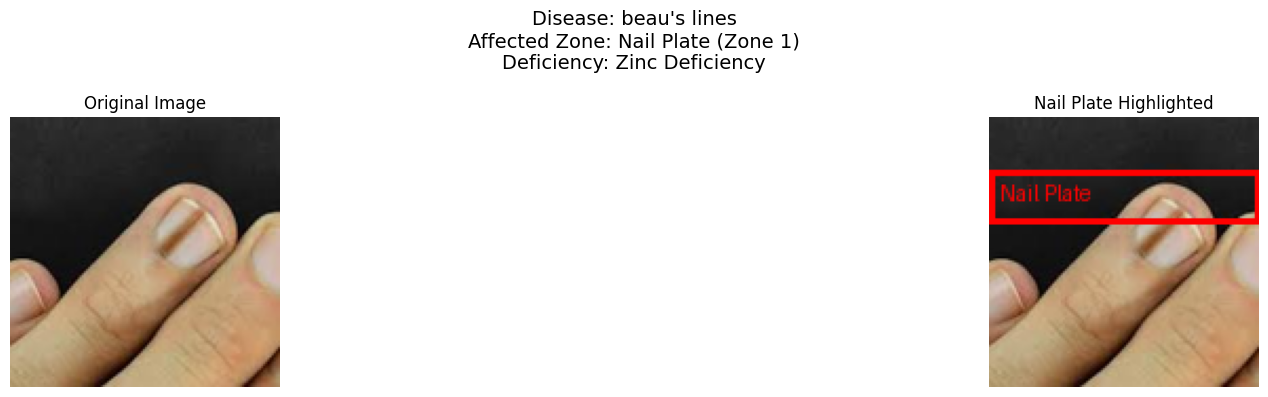

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
import os
from google.colab import files

# --- Load Model ---
model_path = "/content/drive/MyDrive/nail_multitask_model_v2.h5"
IMG_SIZE = 128
NUM_ZONES = 5

print("📥 Loading model...")
model = tf.keras.models.load_model(model_path)

# --- Class Names and Deficiency Map ---
class_names = sorted([
    "aloperia areata", "beau's lines", "bluish nail", "brittle nails", "clubbing",
    "darier's disease", "eczema", "half and half nails(lindsay's nails)", "koilonychia",
    "leukonychia", "mees' lines", "melanonychia", "muehrcke's lines", "onycholysis",
    "onychomycosis", "onychorrhexis", "pale nail", "paronychia", "pitting",
    "red lunula", "splinter hemorrhages", "subungual hematoma", "terry's nails",
    "white nails", "yellow nails"
])

deficiency_map = {
    "aloperia areata": "Iron and vitamin D Deficiency",
    "beau's lines": "Zinc Deficiency",
    "bluish nail": "Vitamin B12 deficiency",
    "darier's disease": "Vitamin A deficiency",
    "eczema": "Vitamin D deficiency",
    "half and half nails(lindsay's nails)": "Tryptophan Deficiency",
    "clubbing": "Oxygen Deficiency, Iodine Deficiency",
    "koilonychia": "Iron Deficiency",
    "leukonychia": "Zinc, Calcium and Iron Deficiency",
    "mees' lines": "Arsenic Poisoning",
    "melanonychia": "Vitamin B12 Deficiency",
    "muehrcke's lines": "Protein Deficiency",
    "pale nail": "Vitamin B12 Deficiency",
    "onycholysis": "Thyroid or Trauma Related",
    "pitting": "Psoriasis or Autoimmune",
    "splinter hemorrhages": "Vitamin C Deficiency",
    "terry's nails": "Liver Disease (Protein Deficiency)",
    "yellow nails": "Lymphatic Obstruction, Vitamin E Deficiency",
    "white nails": "Iron, Zinc, Calcium Deficiency",
    "onychomycosis": "Fungal Infection (Not Nutritional)",
    "paronychia": "Bacterial Infection (Not Nutritional)",
    "brittle nails": "Biotin Deficiency",
    "onychorrhexis": "Iron Deficiency",
    "subungual hematoma": "Trauma or Hemorrhage",
    "red lunula": "Inflammation or circulatory issues"
}

zone_labels = {
    0: "Nail Tip",
    1: "Nail Plate",
    2: "Lunula",
    3: "Proximal Fold",
    4: "Cuticle"
}

# --- Upload Image ---
print("📁 Please upload a nail image...")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# --- Preprocess ---
def preprocess_image(path):
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    return np.expand_dims(np.array(img) / 255.0, axis=0), img

img_array, orig_img = preprocess_image(image_path)

# --- Predict ---
class_probs, zone_mask = model.predict(img_array)
class_idx = np.argmax(class_probs)
disease = class_names[class_idx]
deficiency = deficiency_map.get(disease, "Unknown")

# --- Get Predicted Segmentation Mask ---
seg_mask = np.argmax(zone_mask[0], axis=-1)

# --- Determine Most Affected Zone ---
zone_counts = np.bincount(seg_mask.flatten(), minlength=NUM_ZONES)
zone_affected = int(np.argmax(zone_counts))
zone_name = zone_labels.get(zone_affected, f"Zone {zone_affected}")

# --- Overlay Zone Highlight ---
highlight_img = orig_img.copy().resize((IMG_SIZE, IMG_SIZE))
draw = ImageDraw.Draw(highlight_img)
zone_h = IMG_SIZE // NUM_ZONES
top = zone_affected * zone_h
bottom = (zone_affected + 1) * zone_h
draw.rectangle([(0, top), (IMG_SIZE, bottom)], outline="red", width=3)
draw.text((5, top + 5), f"{zone_name}", fill="red")

# --- Show Results ---
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(orig_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(highlight_img)
plt.title(f"{zone_name} Highlighted")
plt.axis("off")

plt.suptitle(
    f"Disease: {disease}\nAffected Zone: {zone_name} (Zone {zone_affected})\nDeficiency: {deficiency}",
    fontsize=14
)
plt.tight_layout()
plt.show()
